# 07_Skill_Clustering


In [13]:
import pandas as pd
import numpy as np

df = pd.read_csv('../Generated Datasets/master_skill_dataset_v7.csv')
df.head()

,skill,linkedin_demand,salary_premium,current_usage,future_interest,global_adoption_score,growth_rate
0,aws,0.502949,0.571429,0.591886,0.686924,0.892169,0.393336
1,azure,0.288271,0.497905,0.342740,0.392354,0.855730,0.274024
2,c#,0.188676,0.462857,0.435240,0.492004,0.923221,0.296059
3,c++,0.265800,0.837857,0.368799,0.414020,0.892499,0.272088
4,django,0.015208,0.527619,0.155633,0.189361,0.892766,0.239964


In [14]:
feature_cols=['linkedin_demand','salary_premium','current_usage','future_interest','global_adoption_score','growth_rate']
df[feature_cols].describe()

,linkedin_demand,salary_premium,current_usage,future_interest,global_adoption_score,growth_rate
count,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000
mean,0.178579,0.598568,0.332085,0.403007,0.688811,0.335989
std,0.236501,0.203519,0.274673,0.305246,0.382320,0.206030
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.019903,0.488000,0.128681,0.173445,0.813543,0.223332
50%,0.091008,0.577143,0.279073,0.406214,0.875151,0.272587
75%,0.257112,0.767857,0.519297,0.573814,0.923922,0.352896
max,1.000000,1.000000,1.000000,1.000000,0.958204,1.000000


In [15]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X=scaler.fit_transform(df[feature_cols])

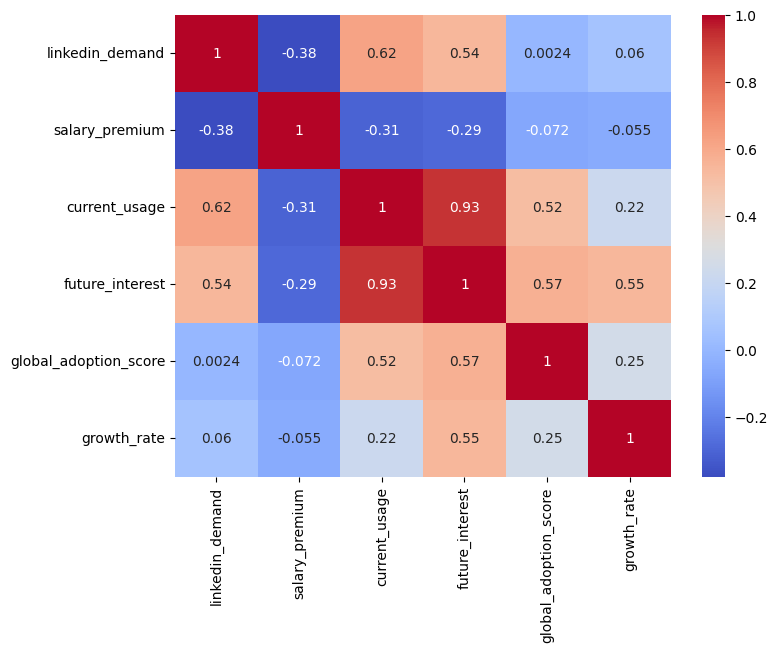

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(df[feature_cols].corr(),annot=True,cmap='coolwarm')
plt.show()

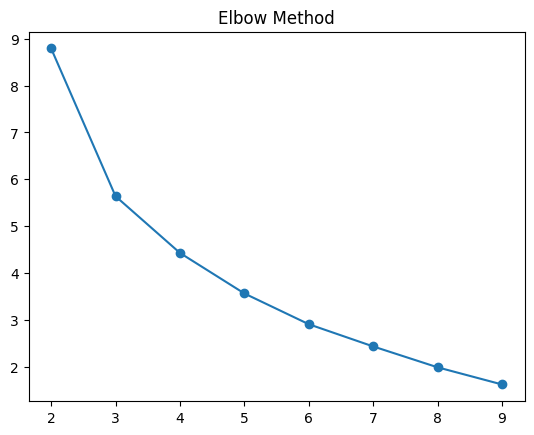

In [17]:
from sklearn.cluster import KMeans
inertia=[]
for k in range(2,10):
    km=KMeans(n_clusters=k,random_state=42,n_init=20)
    km.fit(X)
    inertia.append(km.inertia_)
plt.plot(range(2,10),inertia,marker='o')
plt.title('Elbow Method')
plt.show()

In [18]:
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,10):
    km=KMeans(n_clusters=k,random_state=42,n_init=20)
    labels=km.fit_predict(X)
    scores.append(silhouette_score(X,labels))
pd.DataFrame({'k':range(2,10),'silhouette_score':scores}).sort_values('silhouette_score',ascending=False)

,k,silhouette_score
0,2,0.502792
1,3,0.453903
2,4,0.447941
3,5,0.356693
6,8,0.351274
5,7,0.347632
4,6,0.346869
7,9,0.342489


In [19]:
optimal_k=4
kmeans=KMeans(n_clusters=optimal_k,random_state=42,n_init=20)
df['cluster']=kmeans.fit_predict(X)
df['cluster'].value_counts()

cluster
1    19
0     7
2     5
3     4
Name: count, dtype: int64

In [20]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
components=pca.fit_transform(X)
df['pc1']=components[:,0]
df['pc2']=components[:,1]

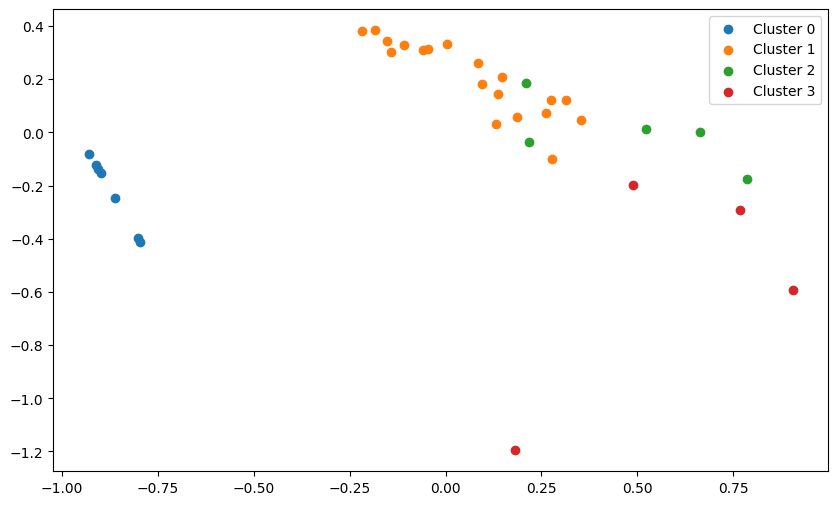

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
for cluster in sorted(df['cluster'].unique()):
    subset=df[df['cluster']==cluster]
    plt.scatter(subset['pc1'],subset['pc2'],label=f'Cluster {cluster}')
plt.legend()
plt.show()

In [22]:
cluster_summary=df.groupby('cluster')[feature_cols].mean().round(3)
cluster_summary

,linkedin_demand,salary_premium,current_usage,future_interest,global_adoption_score,growth_rate
cluster,,,,,,
0,0.093,0.652,0.000,0.000,0.000,0.223
1,0.118,0.628,0.310,0.360,0.889,0.273
2,0.121,0.512,0.499,0.774,0.886,0.751
3,0.687,0.476,0.807,0.850,0.697,0.313


In [23]:
cluster_names = {
    0:'High-Risk',
    1:'Stable',
    2:'Emerging',
    3:'Future-Proof'
}
df['archetype']=df['cluster'].map(cluster_names)

In [24]:
df[['skill','cluster','archetype']].to_csv('../Generated Datasets/skill_clusters.csv',index=False)
cluster_summary.to_csv('../Generated Datasets/cluster_summary.csv')
print('Saved')

Saved
